# Data Exploration - Customer Churn Analysis

This notebook explores the customer churn dataset and provides insights for model development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
sys.path.append('../src')
from data.data_loader import DataLoader
from data.validator import DataValidator
from data.preprocessor import DataPreprocessor

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
%matplotlib inline

## 1. Data Loading and Basic Information

In [2]:
# Dataset source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# Load data
data_loader = DataLoader('../data/raw')
df = data_loader.load_training_data()
print(f"Dataset shape: {df.shape}")
print(f"Dataset info: ")
df.info()

Dataset shape: (7043, 21)
Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  P

In [3]:
print("First 5 rows: ")
df.head()

First 5 rows: 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
preprocessor = DataPreprocessor(is_synthetic=False)
df = preprocessor.fit_transform(df)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               7010 non-null   int64  
 1   SeniorCitizen        7010 non-null   int64  
 2   Partner              7010 non-null   int64  
 3   Dependents           7010 non-null   int64  
 4   tenure               7010 non-null   int64  
 5   PhoneService         7010 non-null   int64  
 6   MultipleLines        7010 non-null   int64  
 7   InternetService      7010 non-null   int64  
 8   OnlineSecurity       7010 non-null   int64  
 9   OnlineBackup         7010 non-null   int64  
 10  DeviceProtection     7010 non-null   int64  
 11  TechSupport          7010 non-null   int64  
 12  StreamingTV          7010 non-null   int64  
 13  StreamingMovies      7010 non-null   int64  
 14  Contract             7010 non-null   int64  
 15  PaperlessBilling     7010 non-null   int64 

In [5]:
print(df.head())
print(df.shape)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        1           0       1             0   
1       1              0        0           0      34             1   
2       1              0        0           0       2             1   
3       1              0        0           0      45             0   
4       0              0        0           0       2             1   

   MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0              1                0               0             2   
1              0                0               2             0   
2              0                0               2             2   
3              1                0               2             0   
4              0                1               0             0   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0            0            0                0         0   
1                 

In [6]:
# Basic statistics
print("Descriptive Statistics: ")
df.describe()


Descriptive Statistics: 


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,avg_monthly_charges,charges_per_month,is_new_customer
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.504280,0.162767,0.484023,0.299429,32.520399,0.902996,0.943509,0.870471,0.789729,0.906705,0.904708,0.796862,0.986020,0.994009,0.690728,0.593153,1.569615,64.888666,2290.353388,0.264907,5.676366,59.212040,0.146790
std,0.500017,0.369180,0.499780,0.458041,24.520441,0.295985,0.948648,0.736546,0.860846,0.881233,0.881019,0.862557,0.886048,0.886138,0.833345,0.491281,1.066924,30.064769,2266.820832,0.441315,8.531230,30.469013,0.353922
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.264384,9.183333,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,35.750000,408.312500,0.000000,1.247721,26.402778,0.000000
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,2.000000,70.400000,1403.875000,0.000000,2.065536,61.231250,0.000000
75%,1.000000,0.000000,1.000000,1.000000,56.000000,1.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,89.900000,3807.837500,1.000000,5.786458,84.916459,0.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,118.750000,8684.800000,1.000000,51.225000,118.969863,1.000000


## 2. Data Quality Assessment

In [7]:
# Check for missing values
print("Missing Values: ")
missing_stats = df.isnull().sum()
missing_pct = (missing_stats / len(df)) * 100
missing_df = pd.DataFrame({
        'Missing Count': missing_stats,
        'Missing Percentage': missing_pct,
    })
print(missing_df[missing_df['Missing Count'] > 0])
    
if missing_df['Missing Count'].sum() == 0:
    print("No missing values found!")

Missing Values: 
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []
No missing values found!


In [8]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
print(f"Percentage of duplicates: {(duplicates/len(df))*100:.2f}%")

Number of duplicate rows: 0
Percentage of duplicates: 0.00%


In [9]:
# Data validation report
validator = DataValidator(is_synthetic=False)
validation_report = validator.generate_report(df)
print(f"Overall validation status: {validation_report['overall_status']}")
print(f"Summary statistics: ")
for key, value in validation_report['summary_statistics'].items():
    print(f"{key}: {value}")

Overall validation status: PASSED
Summary statistics: 
total_rows: 7010
total_columns: 23
missing_values: 0
duplicate_rows: 0
memory_usage_mb: 1.2835693359375


## 3. Target Variable Analysis

Churn Distribution:
No Churn (0): 5153 (73.5%)
Churn (1): 1857 (26.5%)


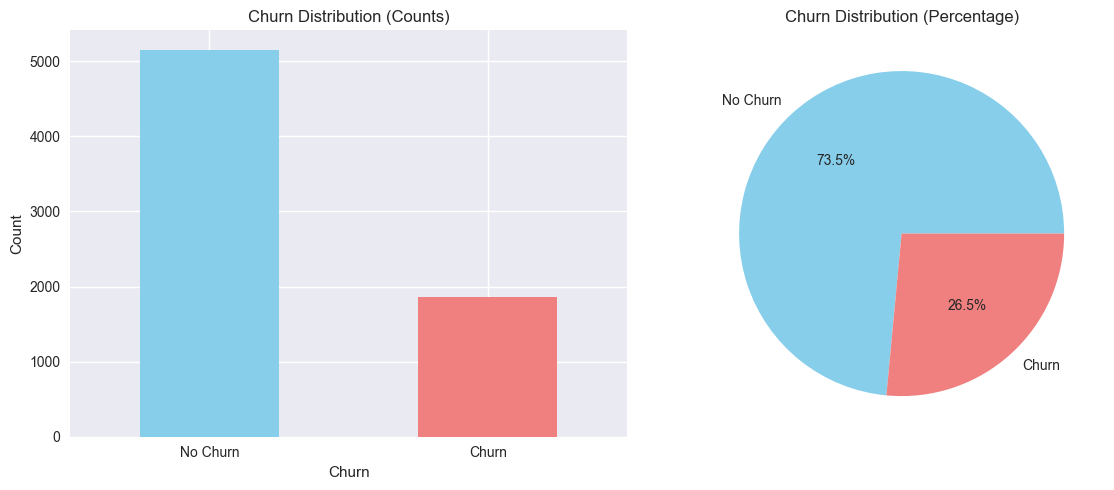

In [10]:
# Analyze target variable distribution
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print("Churn Distribution:")
print(f"No Churn (0): {churn_counts.iloc[0]} ({churn_pct.iloc[0]:.1f}%)")
print(f"Churn (1): {churn_counts.iloc[1]} ({churn_pct.iloc[1]:.1f}%)")
      
# Visualize target distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
churn_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'lightcoral'])
ax1.set_title('Churn Distribution (Counts)')
ax1.set_xlabel('Churn')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['No Churn', 'Churn'], rotation=0)

# Pie chart
ax2.pie(churn_counts.values, labels=['No Churn', 'Churn'], autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])
ax2.set_title('Churn Distribution (Percentage)')
plt.tight_layout()
plt.show()

## 4. Feature Analysis

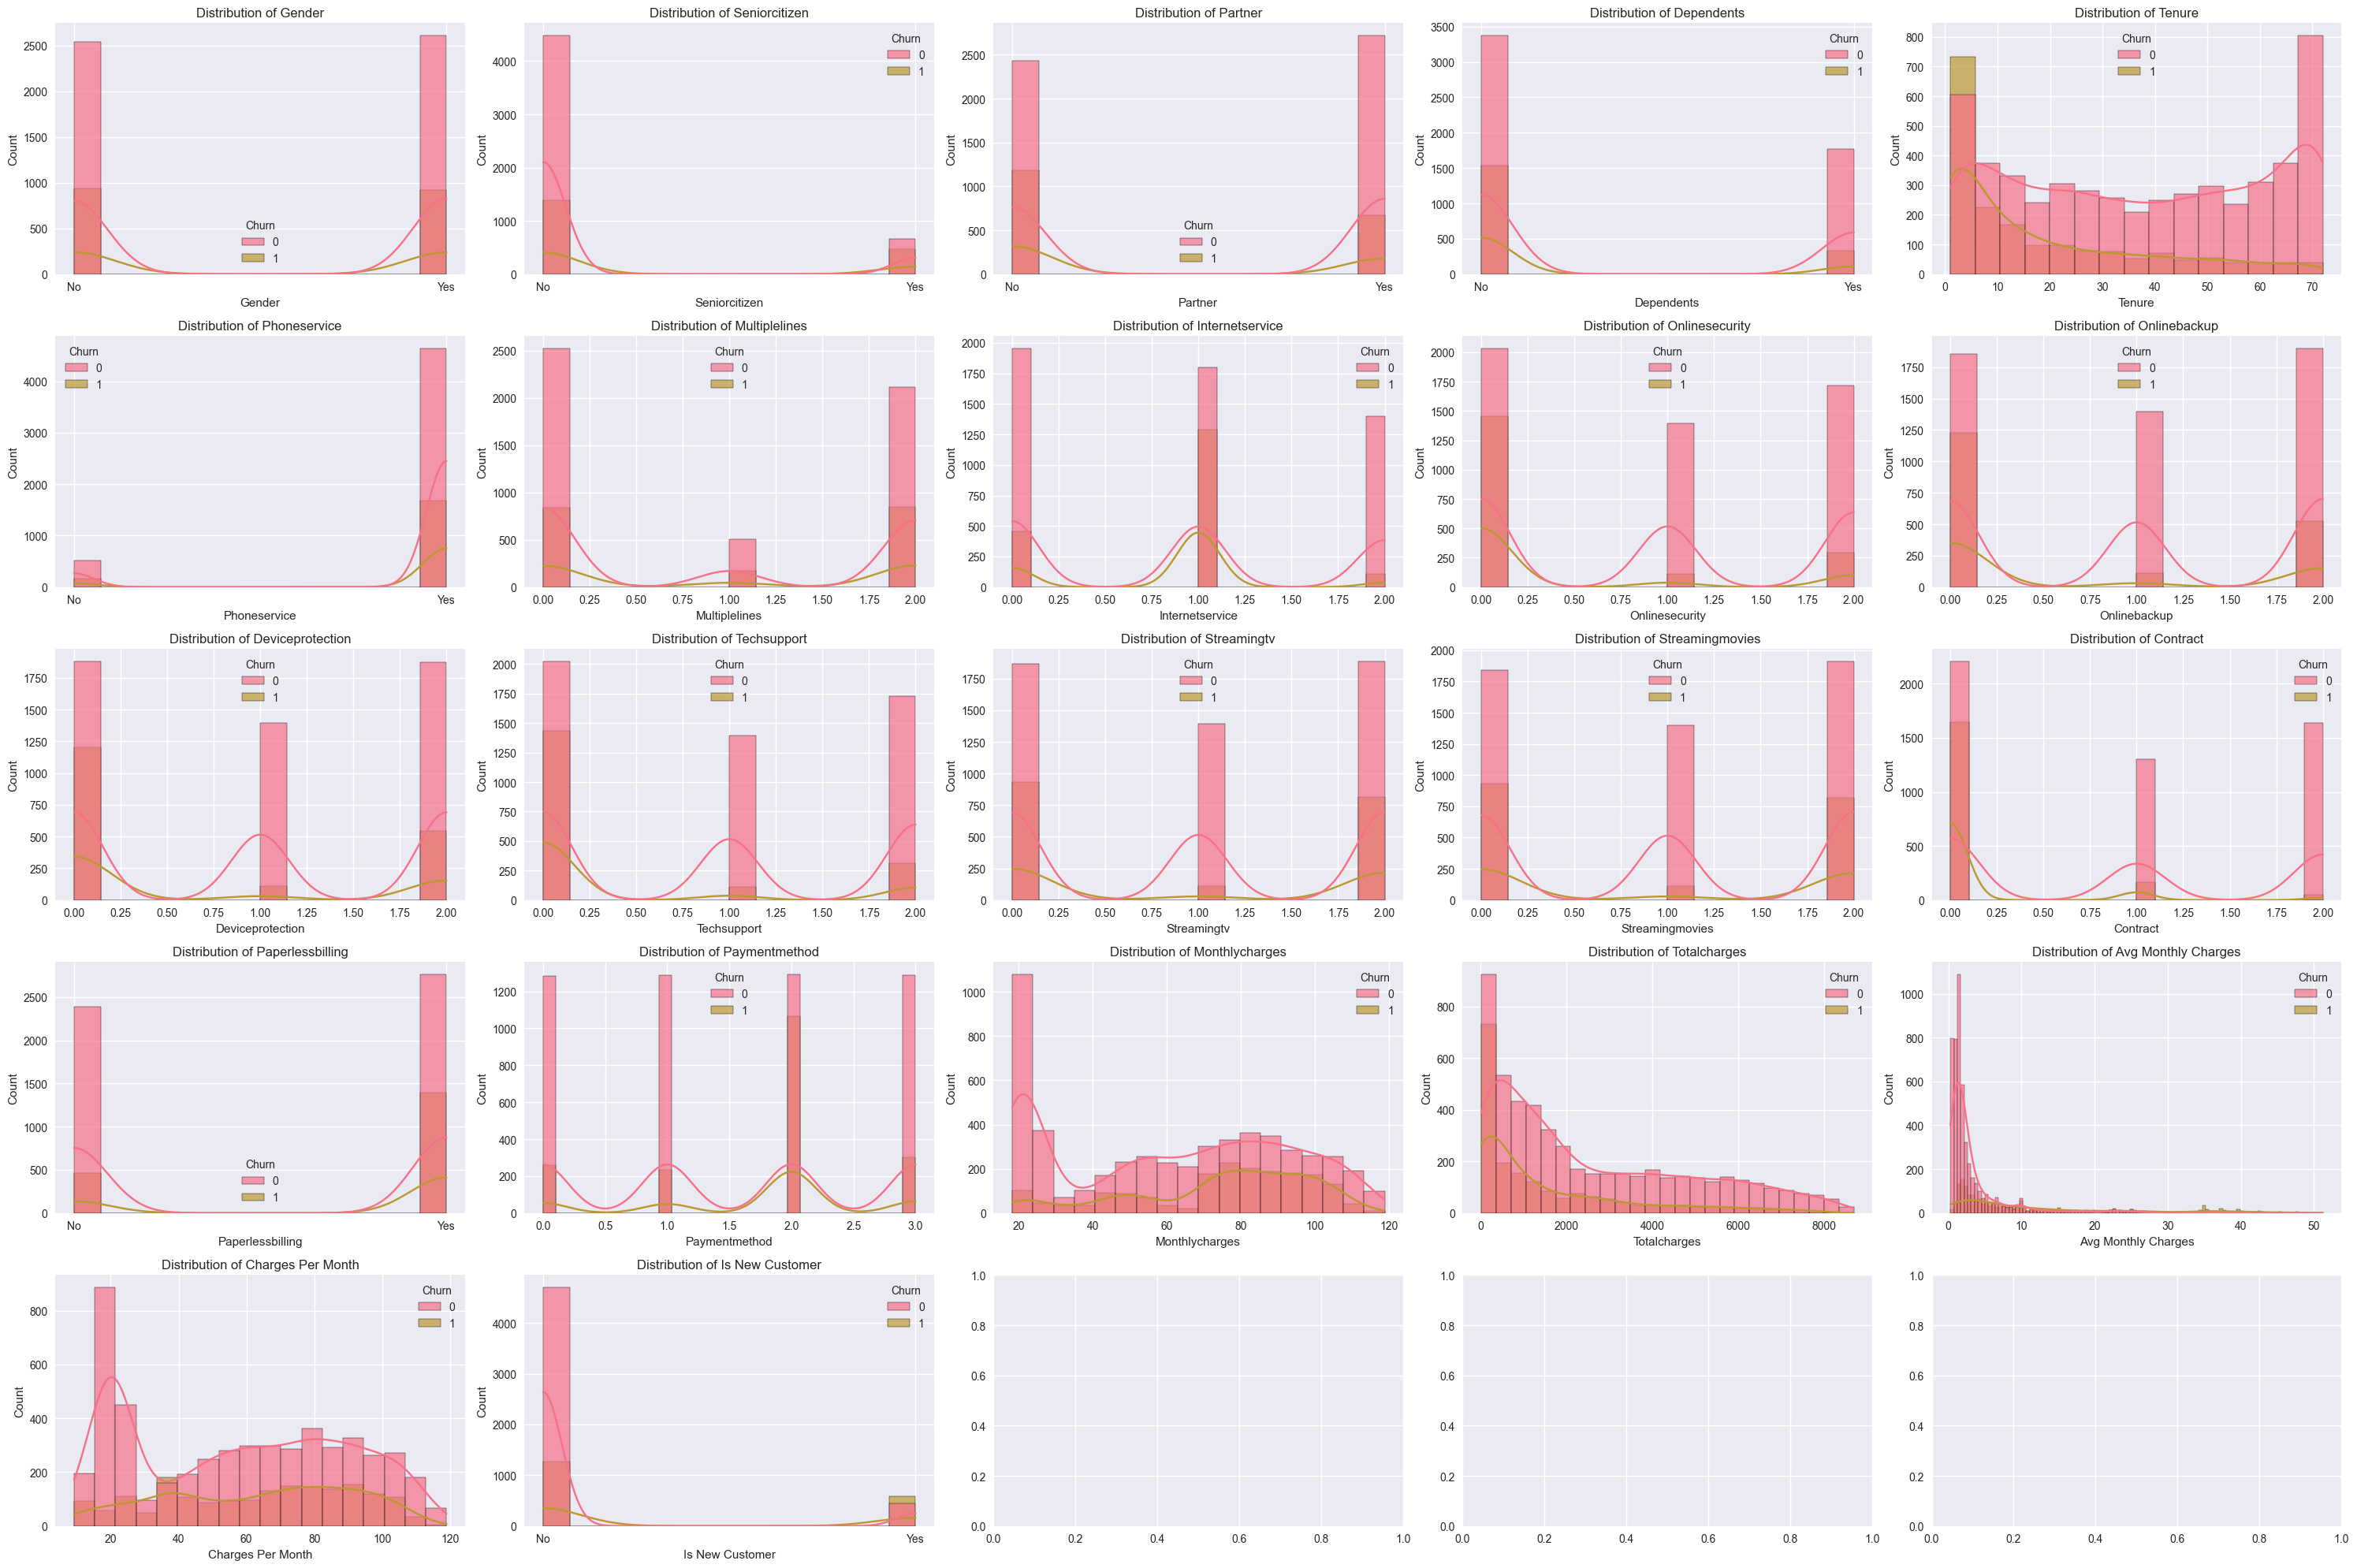

In [11]:
# Analyze numerical features
numerical_features = [i for i in df.columns if i != 'Churn']
fig, axes = plt.subplots(5, 5, figsize=(30, 20))
axes = axes.ravel()
for i, feature in enumerate(numerical_features):
    # Distribution plot
    sns.histplot(data=df, x=feature, hue='Churn', kde=True, ax=axes[i], alpha=0.7)
    axes[i].set_title(f'Distribution of {feature.replace("_", " ").title()}')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    if df[feature].nunique() <= 2:
        axes[i].set_xticks([0, 1])
        axes[i].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

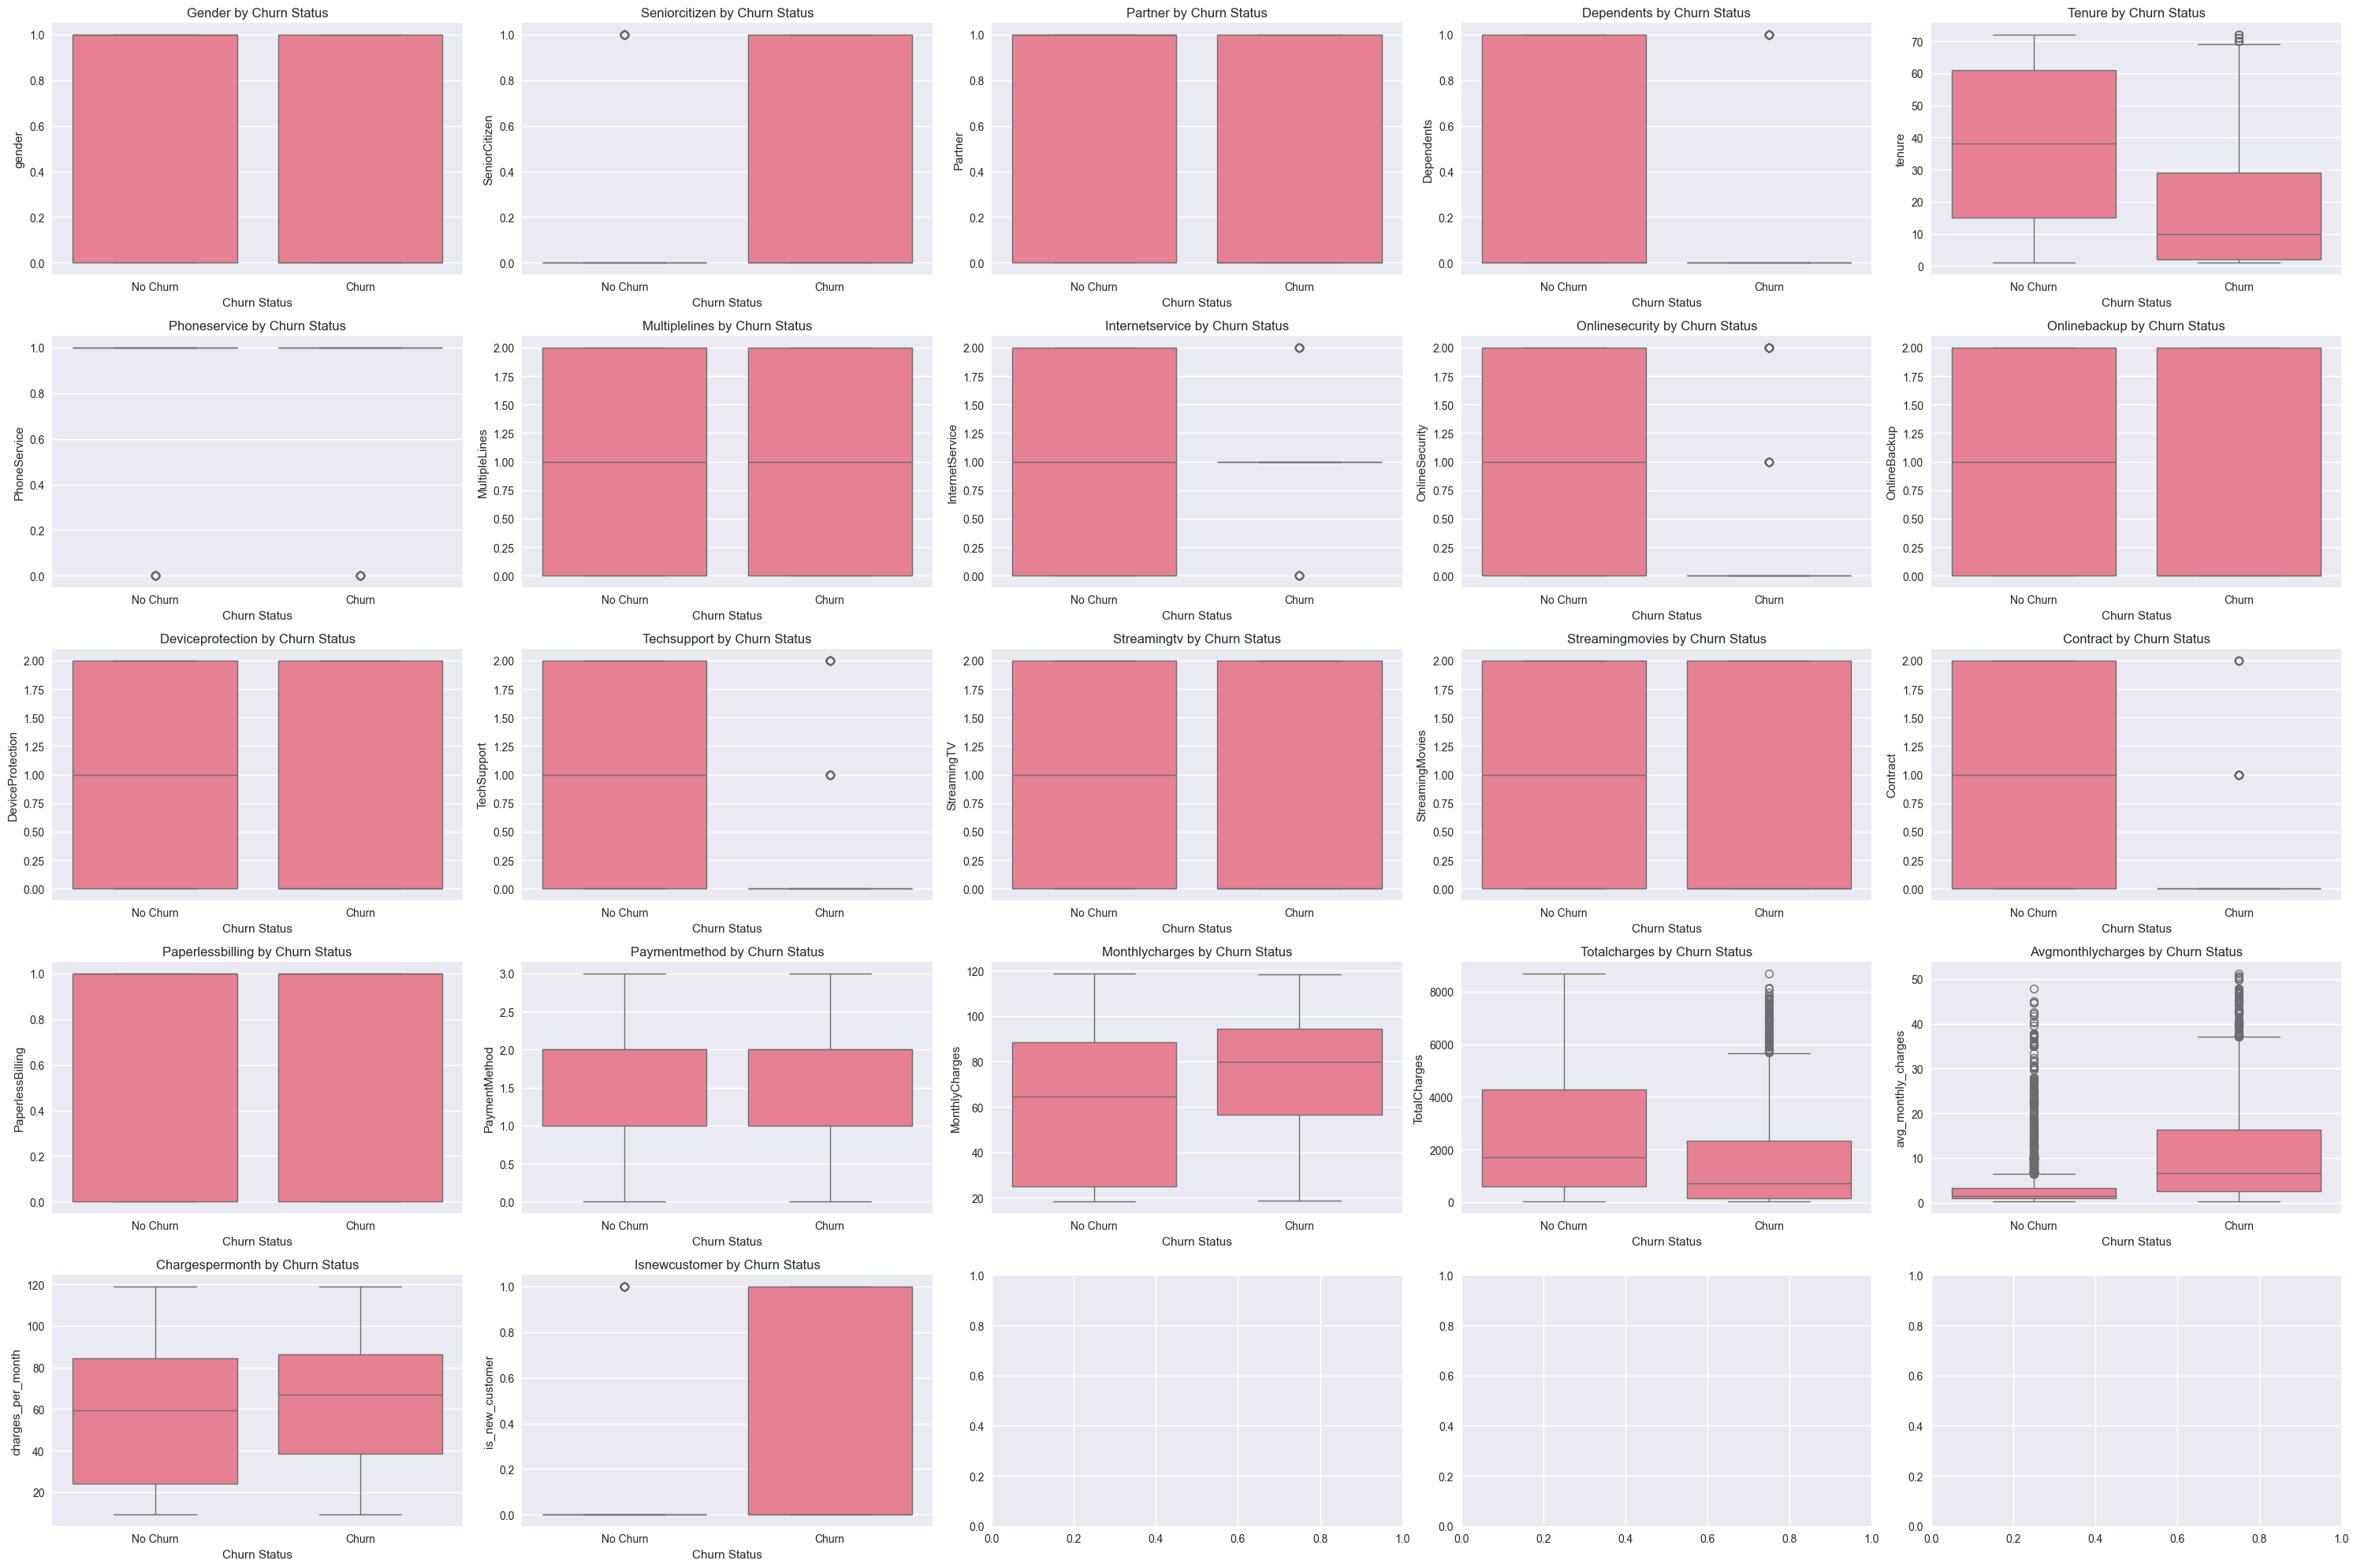

In [12]:
# Box plots for numerical features by churn
fig, axes = plt.subplots(5, 5, figsize=(30, 20))
axes = axes.ravel()
for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df, x='Churn', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature.replace("_", "").title()} by Churn Status')
    axes[i].set_xlabel('Churn Status')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.tight_layout()
plt.show()

In [13]:
# Statistical comparison by churn status
print("Feature Statistics by Churn Status: ")
print("=" * 50)
      
for feature in numerical_features:
    no_churn_stats = df[df['Churn'] == 0][feature].describe()
    churn_stats = df[df['Churn'] == 1][feature].describe()

    print(f"\n{feature.replace('_', ' ').title()}: ")
    print(f"No Churn - Mean: {no_churn_stats['mean']:.2f}, Std: {no_churn_stats['std']:.2f}")
    print(f"Churn - Mean: {churn_stats['mean']:.2f}, Std: {churn_stats['std']:.2f}")

    # Calculate percentage difference
    if no_churn_stats['mean'] != 0:
        pct_diff = ((churn_stats['mean'] - no_churn_stats['mean']) / no_churn_stats['mean']) * 100
        print(f"Difference: {pct_diff:+.1f}%")
    else:
        print("Difference: N/A (division by zero)")

Feature Statistics by Churn Status: 

Gender: 
No Churn - Mean: 0.51, Std: 0.50
Churn - Mean: 0.50, Std: 0.50
Difference: -1.9%

Seniorcitizen: 
No Churn - Mean: 0.13, Std: 0.34
Churn - Mean: 0.26, Std: 0.44
Difference: +97.9%

Partner: 
No Churn - Mean: 0.53, Std: 0.50
Churn - Mean: 0.36, Std: 0.48
Difference: -31.8%

Dependents: 
No Churn - Mean: 0.34, Std: 0.48
Churn - Mean: 0.18, Std: 0.38
Difference: -49.0%

Tenure: 
No Churn - Mean: 37.72, Std: 24.05
Churn - Mean: 18.09, Std: 19.55
Difference: -52.0%

Phoneservice: 
No Churn - Mean: 0.90, Std: 0.30
Churn - Mean: 0.91, Std: 0.29
Difference: +0.8%

Multiplelines: 
No Churn - Mean: 0.92, Std: 0.95
Churn - Mean: 1.01, Std: 0.95
Difference: +9.4%

Internetservice: 
No Churn - Mean: 0.89, Std: 0.80
Churn - Mean: 0.81, Std: 0.52
Difference: -8.8%

Onlinesecurity: 
No Churn - Mean: 0.94, Std: 0.85
Churn - Mean: 0.38, Std: 0.74
Difference: -59.9%

Onlinebackup: 
No Churn - Mean: 1.01, Std: 0.85
Churn - Mean: 0.62, Std: 0.89
Difference: -3

## 5. Correlation Analysis

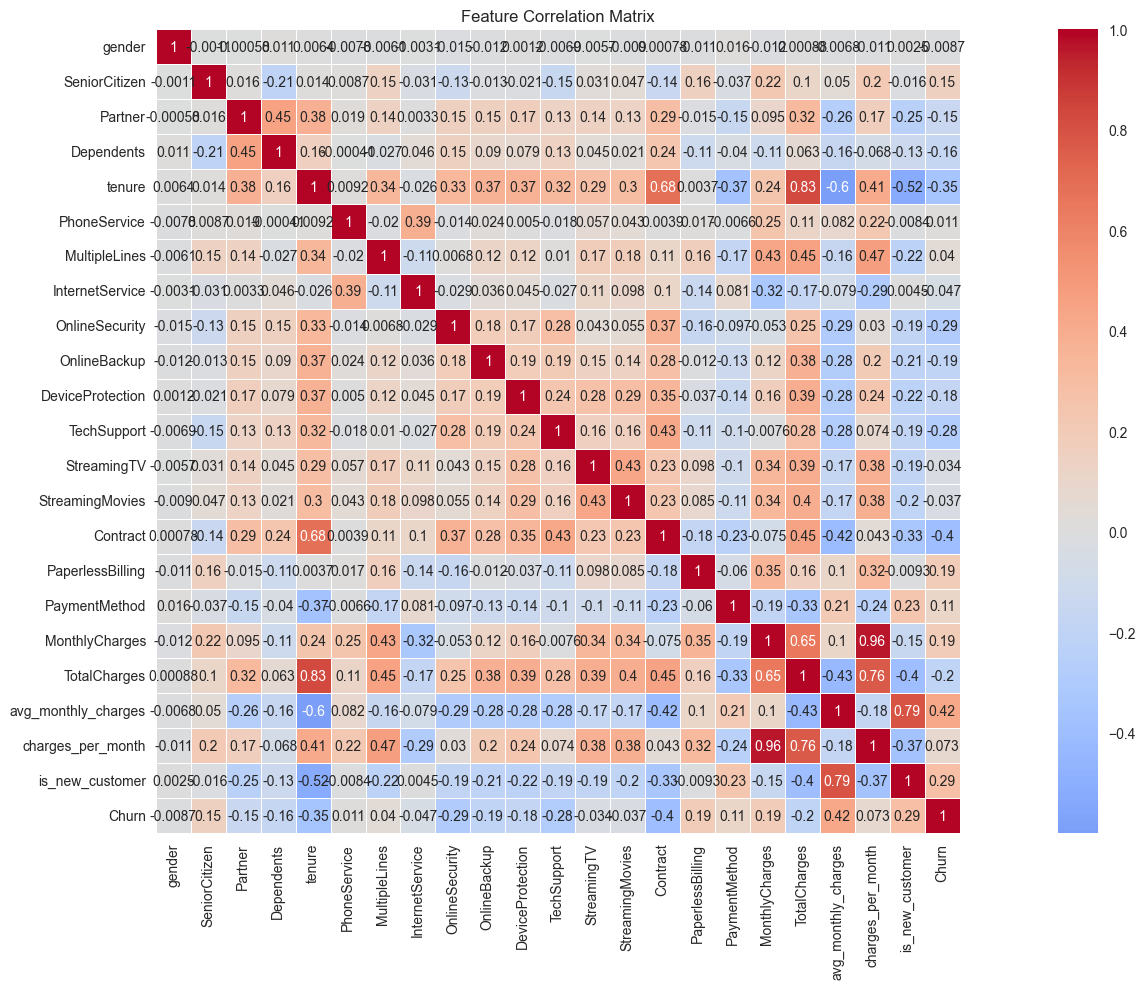

Correlation with Churn:
Avg Monthly Charges: 0.421
Contract: -0.396
Tenure: -0.353
Onlinesecurity: -0.288
Is New Customer: 0.285
Techsupport: -0.281
Totalcharges: -0.198
Monthlycharges: 0.194
Onlinebackup: -0.194
Paperlessbilling: 0.191
Deviceprotection: -0.177
Dependents: -0.162
Seniorcitizen: 0.151
Partner: -0.149
Paymentmethod: 0.107
Charges Per Month: 0.073
Internetservice: -0.047
Multiplelines: 0.040
Streamingmovies: -0.037
Streamingtv: -0.034
Phoneservice: 0.011
Gender: -0.009


In [16]:
# Correlation matrix
correlation_matrix = df[numerical_features + ['Churn']].corr()

plt.figure(figsize=(20, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation with target
print("Correlation with Churn:")
target_corr = correlation_matrix['Churn'].sort_values(key=abs, ascending=False)
for feature, corr in target_corr.items():
    if feature != 'Churn':
        print(f"{feature.replace('_', ' ').title()}: {corr:.3f}")

## 6. Outlier Detection

In [17]:
# Outlier detection using IQR method
def detect_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (series < lower_bound) | (series > upper_bound)

print("Outlier Analysis:")
print("=" * 30)
outlier_summary = []

for feature in numerical_features:
    outliers = detect_outliers_iqr(df[feature])
    outlier_count = outliers.sum()
    outlier_pct = (outlier_count / len(df)) * 100\

    outlier_summary.append({
        'Feature': feature.replace('_', ' ').title(),
        'Outlier Count': outlier_count,
        'Outlier Percentage': f"{outlier_pct:.1f}%"
    })
    print(f"{feature.replace('_', ' ').title()}: {outlier_count} outliers ({outlier_pct:.1f}%)")
              
outlier_df = pd.DataFrame(outlier_summary)
print("Outlier Summary: ")
print(outlier_df)

Outlier Analysis:
Gender: 0 outliers (0.0%)
Seniorcitizen: 1141 outliers (16.3%)
Partner: 0 outliers (0.0%)
Dependents: 0 outliers (0.0%)
Tenure: 0 outliers (0.0%)
Phoneservice: 680 outliers (9.7%)
Multiplelines: 0 outliers (0.0%)
Internetservice: 0 outliers (0.0%)
Onlinesecurity: 0 outliers (0.0%)
Onlinebackup: 0 outliers (0.0%)
Deviceprotection: 0 outliers (0.0%)
Techsupport: 0 outliers (0.0%)
Streamingtv: 0 outliers (0.0%)
Streamingmovies: 0 outliers (0.0%)
Contract: 0 outliers (0.0%)
Paperlessbilling: 0 outliers (0.0%)
Paymentmethod: 0 outliers (0.0%)
Monthlycharges: 0 outliers (0.0%)
Totalcharges: 0 outliers (0.0%)
Avg Monthly Charges: 872 outliers (12.4%)
Charges Per Month: 0 outliers (0.0%)
Is New Customer: 1029 outliers (14.7%)
Outlier Summary: 
                Feature  Outlier Count Outlier Percentage
0                Gender              0               0.0%
1         Seniorcitizen           1141              16.3%
2               Partner              0               0.0%
3   

## 7. Data Distribution Analysis

Distribution Analysis: 


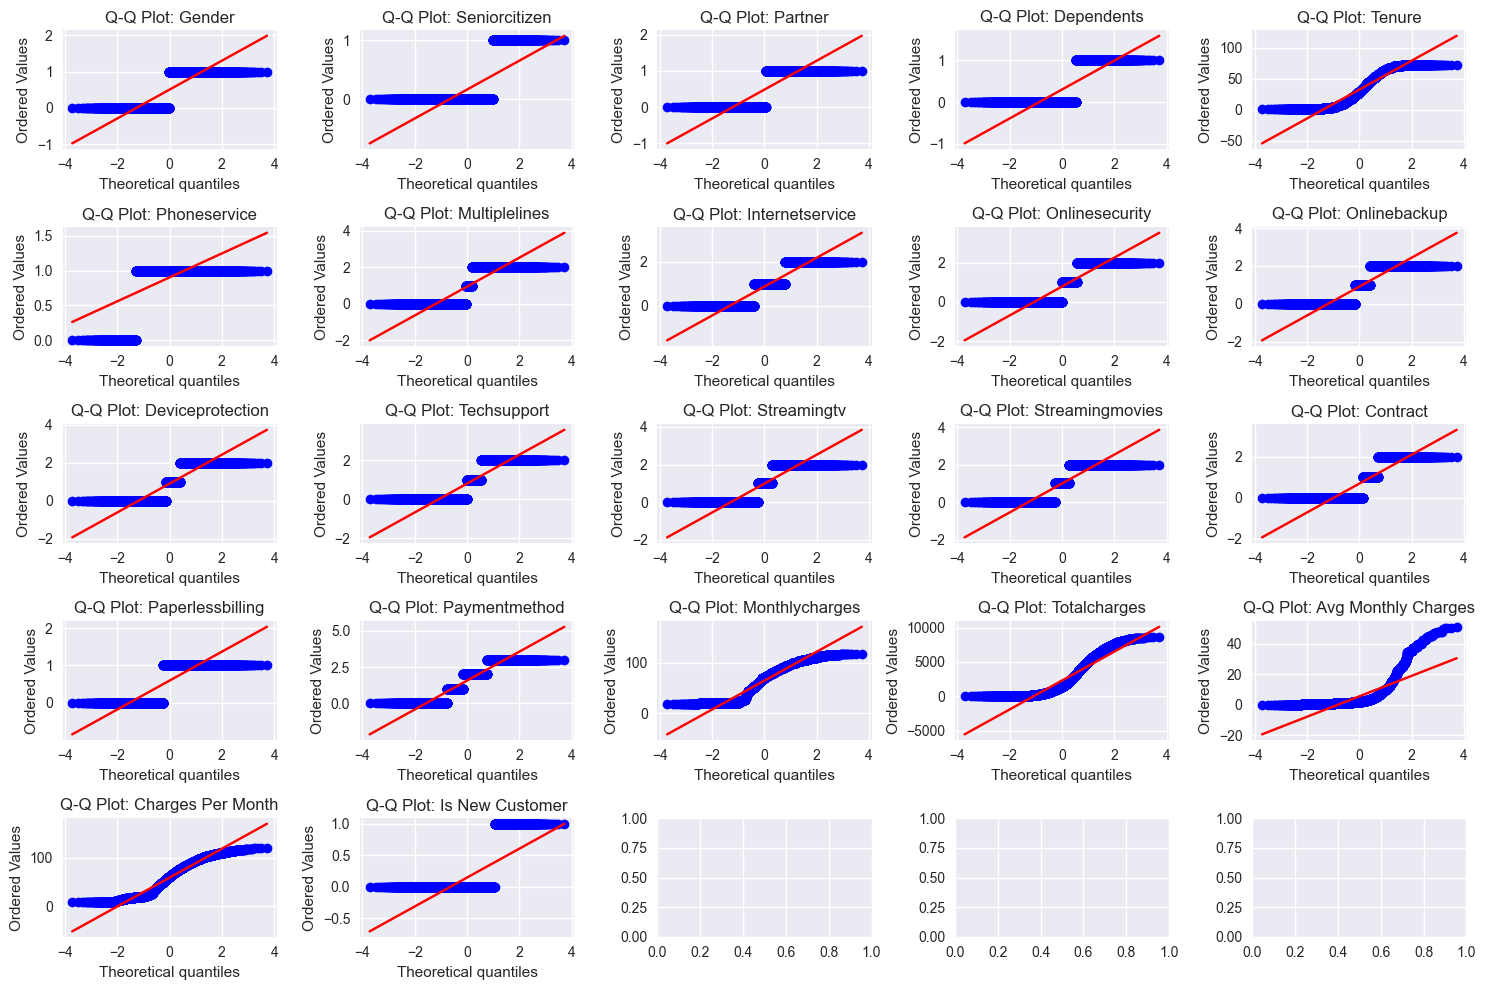

Distribution Statistics:
                Feature Skewness Kurtosis  Distribution
0                Gender   -0.017   -2.000        Normal
1         Seniorcitizen    1.827    1.338  Right-skewed
2               Partner    0.064   -1.996        Normal
3            Dependents    0.876   -1.233  Right-skewed
4                Tenure    0.234   -1.388        Normal
5          Phoneservice   -2.723    5.416   Left-skewed
6         Multiplelines    0.113   -1.879        Normal
7       Internetservice    0.209   -1.139        Normal
8        Onlinesecurity    0.418   -1.523        Normal
9          Onlinebackup    0.182   -1.688        Normal
10     Deviceprotection    0.186   -1.686        Normal
11          Techsupport    0.403   -1.537        Normal
12          Streamingtv    0.027   -1.726        Normal
13      Streamingmovies    0.012   -1.726        Normal
14             Contract    0.630   -1.272  Right-skewed
15     Paperlessbilling   -0.379   -1.856        Normal
16        Paymentmethod

In [21]:
# Analyze distributions and skewness
from scipy import stats

print("Distribution Analysis: ")
print("=" * 30)

fig, axes = plt.subplots(5, 5, figsize=(15, 10))
axes = axes.ravel()

distribution_stats = []

for i, feature in enumerate(numerical_features):
    # Calculate skewness and kurtosis
    skewness = stats.skew(df[feature])
    kurtosis = stats.kurtosis(df[feature])

    distribution_stats.append({
        'Feature': feature.replace('_', ' ').title(),
        'Skewness': f"{skewness:.3f}",
        'Kurtosis': f"{kurtosis:.3f}",
        'Distribution': 'Normal' if abs(skewness) < 0.5 else ('Right-skewed' if skewness > 0 else 'Left-skewed')
    })

    # Q-Q plot
    stats.probplot(df[feature], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {feature.replace("_", " ").title()}')

plt.tight_layout()
plt.show()

# Display distribution statistics
dist_df = pd.DataFrame(distribution_stats)
print("Distribution Statistics:")
print(dist_df)

## 8. Key Insights and Recommendations

In [22]:
# Generate insights based on analysis
insights = []

# Target variable balance
churn_rate = df['Churn'].mean()
if churn_rate < 0.1 or churn_rate > 0.9:
    insights.append(f"Dataset is imbalanced (churn rate: {churn_rate:.1%}). Consider sampling techniques.")
else:
    insights.append(f"Dataset is reasonably balanced (churn rate: {churn_rate:.1%}).")

# Missing values
if df.isnull().sum().sum() == 0:
    insights.append("No missing values detected in the dataset.")
else:
    insights.append(f"Missing values detected. Implement imputation strategy.")

# Outliers
total_outliers = sum([detect_outliers_iqr(df[feature]).sum() for feature in numerical_features])
outlier_pct = (total_outliers / (len(df) * len(numerical_features))) * 100
if outlier_pct > 5:
    insights.append(f"High outlier rate ({outlier_pct:.1f}%). Consider outlier treatment.")
else:
    insights.append(f"Outlier rate is acceptable ({outlier_pct:.1f}%).")

# Feature correlations
high_corr_pairs = []
corr_matrix = df[numerical_features].corr()
for i in range(len(numerical_features)):
    for j in range(i+1, len(numerical_features)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((numerical_features[i], numerical_features[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    insights.append(f"High correlation detected between features. Consider feature selection.")
else:
    insights.append("No high correlation between features detected.")

# Most predictive features
target_corr = df[numerical_features + ['Churn']].corr()['Churn'].abs().sort_values(ascending=False)
top_feature = target_corr.index[1]  # Exclude 'churn' itself
insights.append(f"Most predictive feature: {top_feature.replace('_', ' ').title()} (correlation: {target_corr[top_feature]:.3f})")

print("Key Insights and Recommendations:")
print("=" * 50)
for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

Key Insights and Recommendations:
1. Dataset is reasonably balanced (churn rate: 26.5%).
2. No missing values detected in the dataset.
3. Outlier rate is acceptable (2.4%).
4. High correlation detected between features. Consider feature selection.
5. Most predictive feature: Avg Monthly Charges (correlation: 0.421)


## 9. Data Export for Model Development

In [23]:
# Save insights and statistics for later use
exploration_summary = {
    'dataset_shape': df.shape,
    'churn_rate': churn_rate,
    'missing_values': df.isnull().sum().to_dict(),
    'feature_correlations': df[numerical_features + ['Churn']].corr()['Churn'].to_dict(),
    'outlier_counts': {feature: detect_outliers_iqr(df[feature]).sum() for feature in numerical_features},
    'distribution_stats': {feature: {'skewness': stats.skew(df[feature]), 'kurtosis': stats.kurtosis(df[feature])} for feature in numerical_features}
    }

# Save to file
import json
with open('../data/processed/exploration_summary.json', 'w') as f:
    json.dump(exploration_summary, f, indent=2, default=str)

print("Exploration summary saved to '../data/processed/exploration_summary.json'")
print("Data exploration completed! Ready for model development.")

Exploration summary saved to '../data/processed/exploration_summary.json'
Data exploration completed! Ready for model development.
